# Visualising the preprocessed data

Loads one subject/run's saved `.npy` outputs and draws:
1. **ROI time series** - a few parcels' signals over time
2. **Carpet plot** - all parcels x time as a heatmap
3. **Functional connectivity** - parcel x parcel correlation
4. **Parcellated brain map** - one timepoint painted back onto the brain
5. **Atlas overlay** - the Schaefer-1000 parcellation on a brain

Edit `CORTICAL_FILE` below to point at any saved cortical_parcels .npy file.

In [1]:
import os, sys
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import plotting

PROJECT = r"C:\TRIBE_Preprocessing"
sys.path.append(PROJECT)
import helpers.helpers_narratives as H            # any helper works - they share get_cortical_atlas()

# --- pick which saved file to visualise ---
CORTICAL_FILE = os.path.join(PROJECT, "outputs", "narratives", "sub-001",
                             "sub-001_task-pieman_run-1_cortical_parcels.npy")

cortex = np.load(CORTICAL_FILE)            # shape (T, 1000)
print("cortical parcels:", cortex.shape)
cortical_atlas = H.get_cortical_atlas()    # for the brain-map / overlay plots

cortical parcels: (449, 1000)
[fetch_atlas_schaefer_2018] Dataset found in C:\TRIBE_Preprocessing\atlases\schaefer_2018


## 1. ROI time series (5 example parcels)

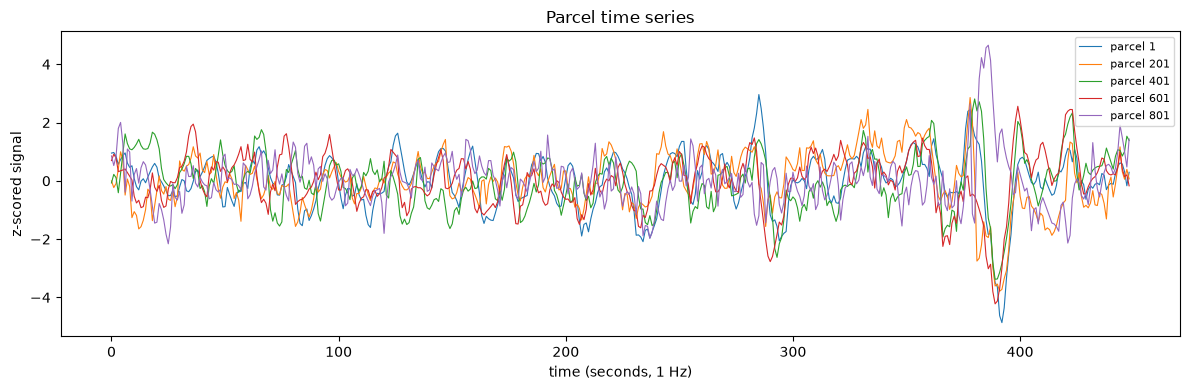

In [2]:
plt.figure(figsize=(12, 4))
for p in [0, 200, 400, 600, 800]:          # 5 example parcels
    plt.plot(cortex[:, p], label=f"parcel {p+1}", linewidth=0.8)
plt.xlabel("time (seconds, 1 Hz)"); plt.ylabel("z-scored signal")
plt.title("Parcel time series"); plt.legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 2. Carpet plot (all 1000 parcels x time)

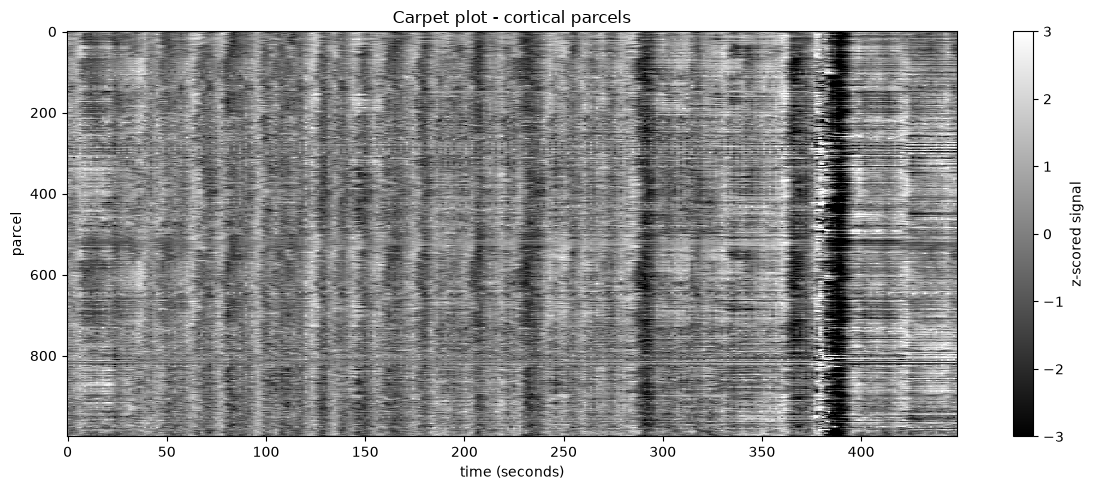

In [3]:
plt.figure(figsize=(12, 5))
plt.imshow(cortex.T, aspect="auto", cmap="gray", vmin=-3, vmax=3,
           interpolation="nearest")
plt.xlabel("time (seconds)"); plt.ylabel("parcel")
plt.title("Carpet plot - cortical parcels"); plt.colorbar(label="z-scored signal")
plt.tight_layout(); plt.show()

## 3. Functional connectivity (parcel x parcel correlation)

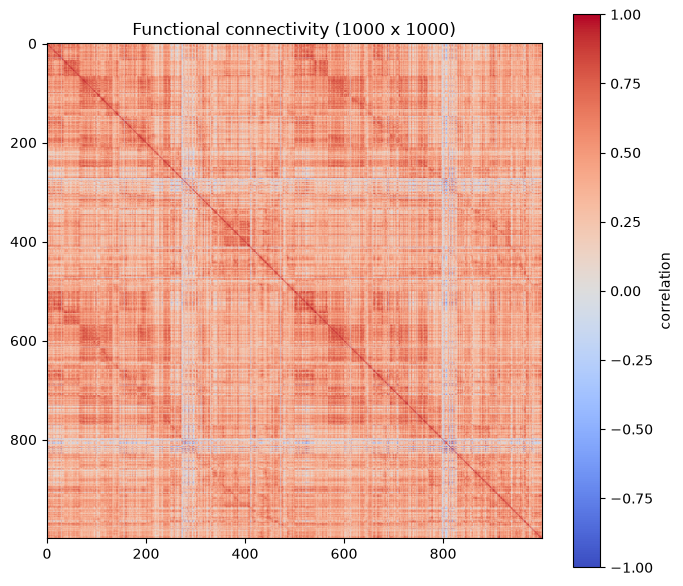

In [4]:
fc = np.corrcoef(cortex.T)                  # (1000, 1000)
plt.figure(figsize=(7, 6))
plt.imshow(fc, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Functional connectivity (1000 x 1000)"); plt.colorbar(label="correlation")
plt.tight_layout(); plt.show()

## 4. Parcellated brain map (one timepoint, painted back onto the brain)

This is literally "the fMRI after parcellation": we take each parcel's value at one
timepoint and colour that whole region with it.

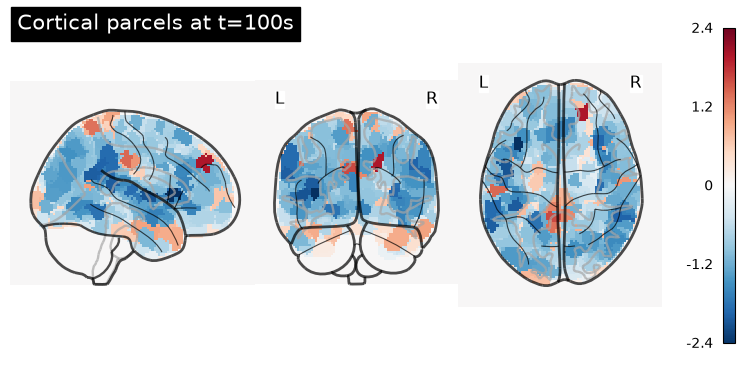

In [5]:
def parcels_to_brain(values, atlas_img):
    """Paint each parcel's value onto every voxel of that parcel (column i -> label i+1)."""
    labels = np.asarray(atlas_img.dataobj).astype(int)
    out = np.zeros(labels.shape, dtype=np.float32)
    for i, v in enumerate(values):
        out[labels == (i + 1)] = v
    return nib.Nifti1Image(out, atlas_img.affine)

t = 100                                     # pick a timepoint
brain = parcels_to_brain(cortex[t], cortical_atlas)
plotting.plot_glass_brain(brain, colorbar=True, plot_abs=False,
                          title=f"Cortical parcels at t={t}s")
plotting.show()

## 5. Atlas overlay (the Schaefer-1000 parcellation itself)

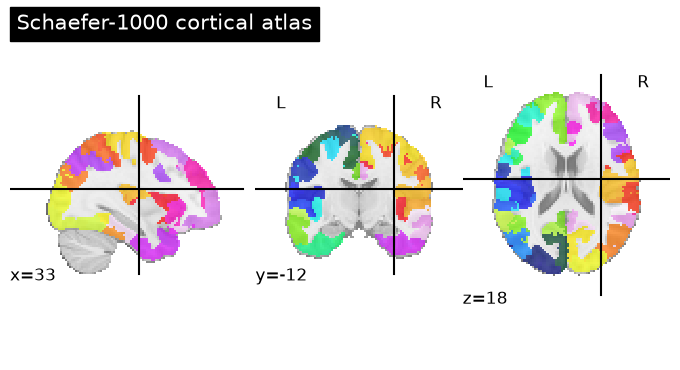

In [6]:
plotting.plot_roi(cortical_atlas, title="Schaefer-1000 cortical atlas", colorbar=False)
plotting.show()